# Task-05: Traffic Accident Data Analysis

Analyze patterns related to road conditions, weather, time of day, and accident hotspots using the US Accidents dataset.


In [2]:
!pip -q install folium
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, folium, os
from folium.plugins import HeatMap
sns.set_theme(style="whitegrid")
df=pd.read_csv("/content/US_Traffic_Accident_Task05_Dataset (2).csv")
df["Start_Time"]=pd.to_datetime(df["Start_Time"]); df["End_Time"]=pd.to_datetime(df["End_Time"])
print(df.shape); display(df.head())


(12000, 26)


,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,State,Road_Condition,...,Amenity,Bump,Crossing,Junction,Railway,Roundabout,Station,Stop,Traffic_Signal,Sunrise_Sunset
0,A-1,4,2017-06-16 00:06:00,2017-06-16 01:11:43.278365,38.686682,-78.221143,0.31,Arlington,VA,Rural Road,...,False,False,True,False,False,False,False,False,False,Night
1,A-2,2,2017-03-18 20:01:00,2017-03-18 21:02:34.572489,32.860952,-83.999798,0.16,Augusta,GA,Interstate,...,True,False,False,False,False,False,False,False,False,Night
2,A-3,3,2020-10-07 10:20:00,2020-10-07 10:32:03.217935,35.842980,-121.577066,0.12,San Diego,CA,Urban Road,...,True,False,True,False,False,False,False,False,False,Day
3,A-4,3,2019-09-13 10:55:00,2019-09-13 11:25:30.279509,46.180889,-120.961081,0.61,Tacoma,WA,Urban Road,...,False,False,False,False,False,False,False,False,False,Day
4,A-5,2,2018-07-29 16:03:00,2018-07-29 17:06:33.570765,39.432392,-88.155839,0.19,Springfield,IL,Interstate,...,False,False,False,False,False,False,False,False,False,Day


In [3]:
print("Duplicates:",df.duplicated().sum())
display(df.isnull().sum().sort_values(ascending=False).head(15))
df=df.drop_duplicates().dropna(subset=["Start_Time","Start_Lat","Start_Lng","Severity"]).copy()
df["Hour"]=df.Start_Time.dt.hour
df["Day_of_Week"]=df.Start_Time.dt.day_name()
df["Month"]=df.Start_Time.dt.month_name()
df["Year"]=df.Start_Time.dt.year
df["Weekend"]=df.Start_Time.dt.dayofweek>=5
df["Time_of_Day"]=pd.cut(df["Hour"],[-1,4,11,16,20,23],labels=["Night","Morning","Afternoon","Evening","Night"],ordered=False)
print("Cleaned shape:",df.shape)


Duplicates: 0


,0
ID,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
Distance(mi),0
City,0
State,0
Road_Condition,0


Cleaned shape: (12000, 32)


## 1. Accident Severity


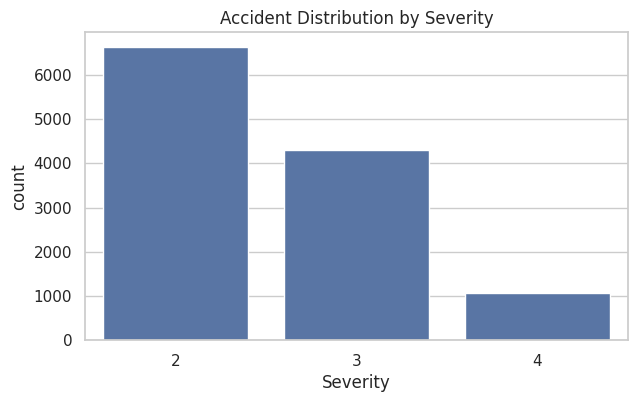

Average severity: 2.54


In [4]:
plt.figure(figsize=(7,4)); sns.countplot(data=df,x="Severity"); plt.title("Accident Distribution by Severity"); plt.show()
print("Average severity:",round(df.Severity.mean(),2))


## 2. Time-of-Day Patterns


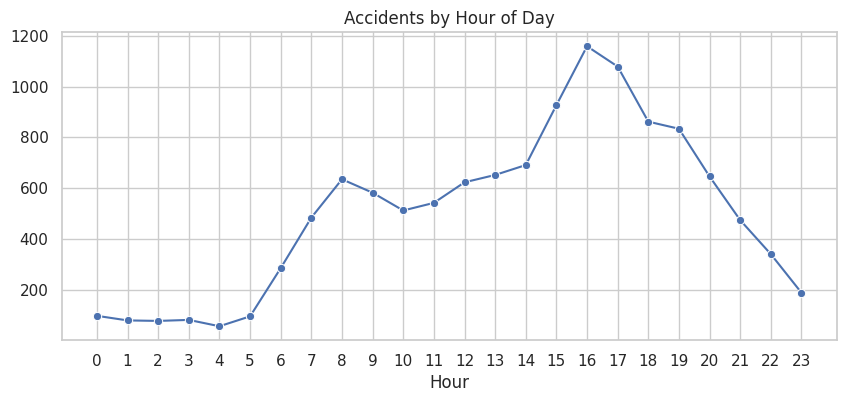

Peak hour: 16


In [5]:
hour_counts=df.groupby("Hour").size()
plt.figure(figsize=(10,4)); sns.lineplot(x=hour_counts.index,y=hour_counts.values,marker="o"); plt.xticks(range(24)); plt.title("Accidents by Hour of Day"); plt.show()
print("Peak hour:",int(hour_counts.idxmax()))


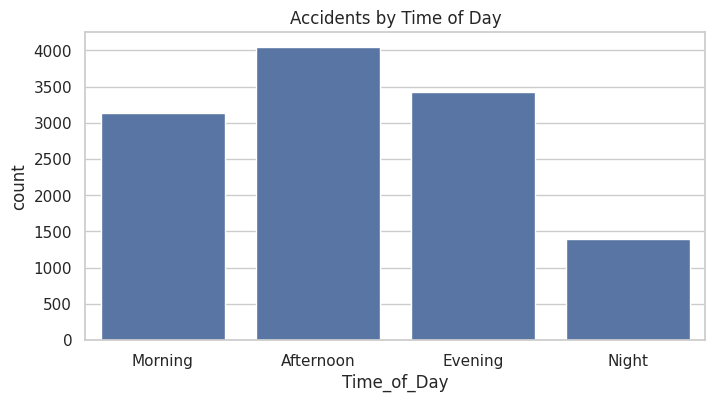

In [6]:
order=["Morning","Afternoon","Evening","Night"]
plt.figure(figsize=(8,4)); sns.countplot(data=df,x="Time_of_Day",order=order); plt.title("Accidents by Time of Day"); plt.show()


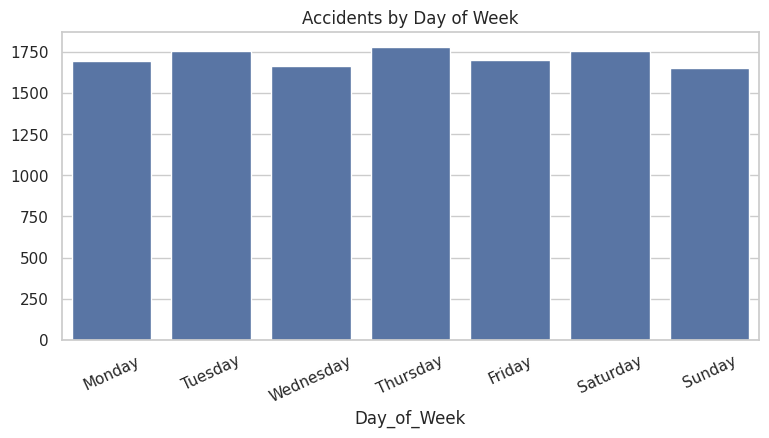

In [7]:
days=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]; counts=df.Day_of_Week.value_counts().reindex(days)
plt.figure(figsize=(9,4)); sns.barplot(x=counts.index,y=counts.values); plt.xticks(rotation=25); plt.title("Accidents by Day of Week"); plt.show()


## 3. Road Conditions


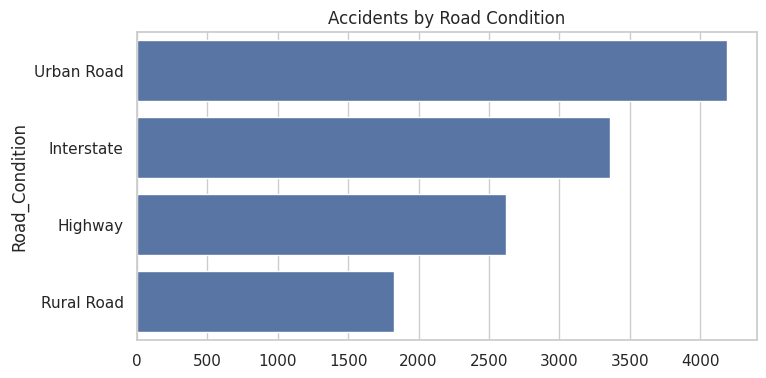

In [8]:
rc=df.Road_Condition.value_counts()
plt.figure(figsize=(8,4)); sns.barplot(x=rc.values,y=rc.index); plt.title("Accidents by Road Condition"); plt.show()


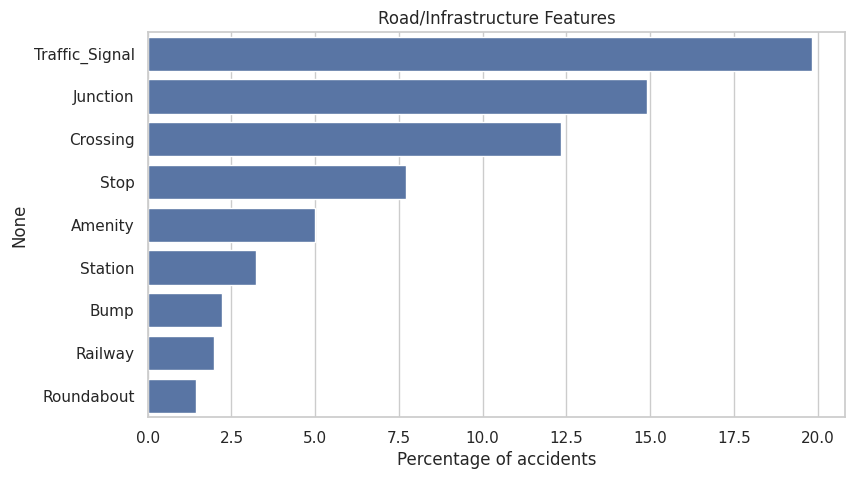

In [9]:
features=["Bump","Crossing","Junction","Railway","Roundabout","Station","Stop","Traffic_Signal","Amenity"]
rates=df[features].mean().sort_values(ascending=False)*100
plt.figure(figsize=(9,5)); sns.barplot(x=rates.values,y=rates.index); plt.xlabel("Percentage of accidents"); plt.title("Road/Infrastructure Features"); plt.show()


## 4. Weather Patterns


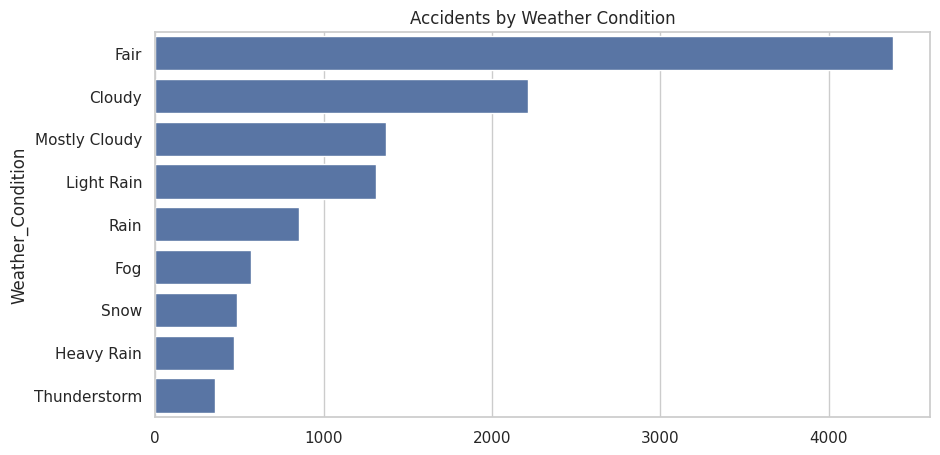

In [10]:
wc=df.Weather_Condition.value_counts()
plt.figure(figsize=(10,5)); sns.barplot(x=wc.values,y=wc.index); plt.title("Accidents by Weather Condition"); plt.show()


,Average Severity
Weather_Condition,
Thunderstorm,3.41
Heavy Rain,2.55
Rain,2.53
Snow,2.52
Mostly Cloudy,2.52
Light Rain,2.51
Cloudy,2.50
Fair,2.50
Fog,2.50


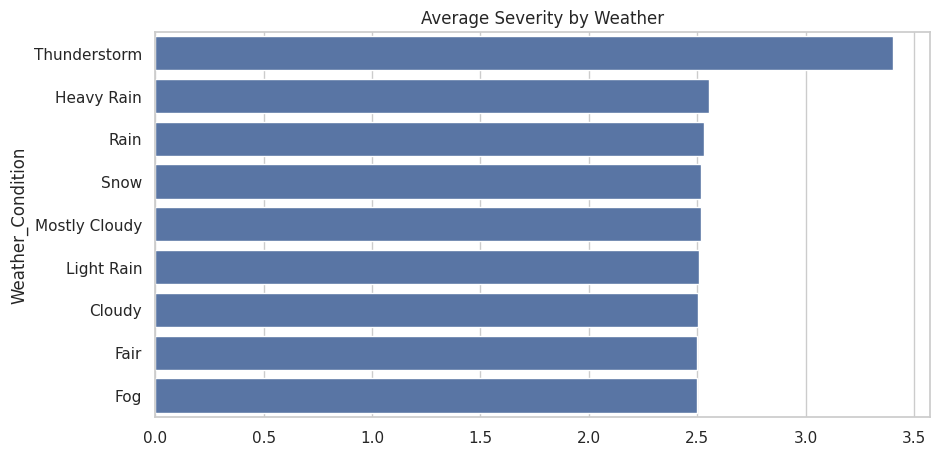

In [11]:
ws=df.groupby("Weather_Condition").Severity.mean().sort_values(ascending=False)
display(ws.round(2).to_frame("Average Severity"))
plt.figure(figsize=(10,5)); sns.barplot(x=ws.values,y=ws.index); plt.title("Average Severity by Weather"); plt.show()


## 5. Day × Hour Heatmap


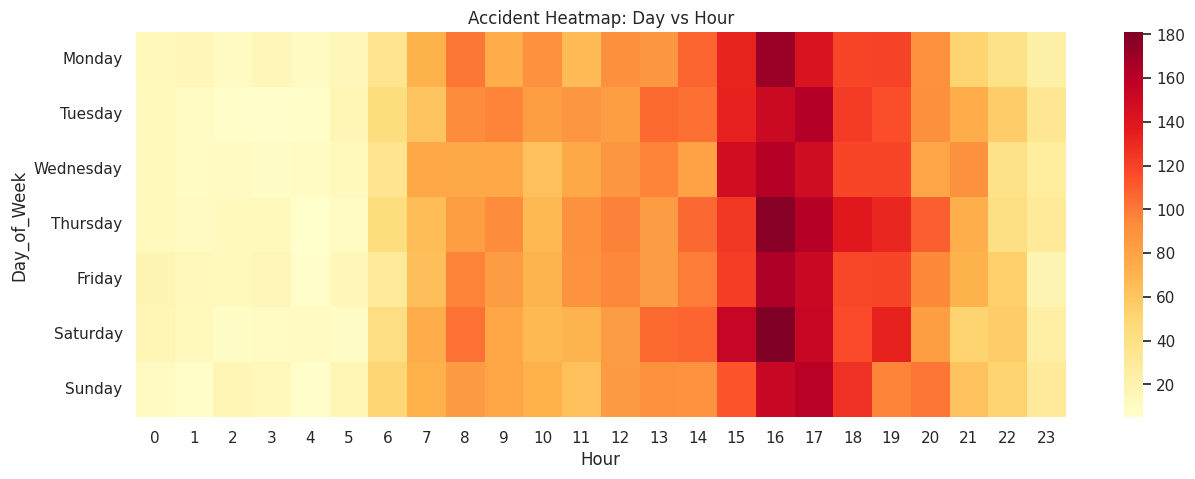

In [12]:
heat=df.pivot_table(index="Day_of_Week",columns="Hour",values="ID",aggfunc="count").reindex(days)
plt.figure(figsize=(15,5)); sns.heatmap(heat,cmap="YlOrRd"); plt.title("Accident Heatmap: Day vs Hour"); plt.show()


## 6. Accident Hotspots


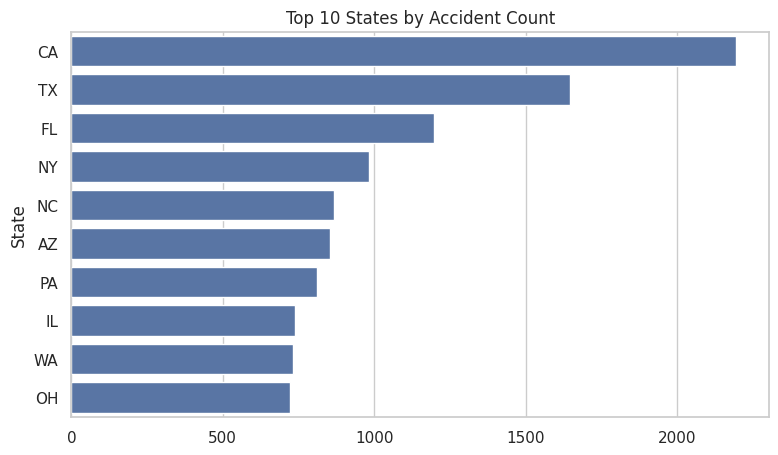

In [13]:
top=df.State.value_counts().head(10)
plt.figure(figsize=(9,5)); sns.barplot(x=top.values,y=top.index); plt.title("Top 10 States by Accident Count"); plt.show()


In [14]:
m=df.sample(min(2500,len(df)),random_state=42)
center=[m.Start_Lat.mean(),m.Start_Lng.mean()]
accident_map=folium.Map(location=center,zoom_start=4)
HeatMap(m[["Start_Lat","Start_Lng"]].values.tolist(),radius=8,blur=10,min_opacity=.25).add_to(accident_map)
display(accident_map)


## 7. Key Findings and Conclusion


In [15]:
print("Total accidents:",len(df))
print("Most common road condition:",df.Road_Condition.mode()[0])
print("Most common weather:",df.Weather_Condition.mode()[0])
print("Peak hour:",int(df.groupby("Hour").size().idxmax()))
print("Most common time period:",df.Time_of_Day.mode()[0])
print("State with most accidents:",df.State.mode()[0])
print("Highest average severity weather:",ws.index[0])


Total accidents: 12000
Most common road condition: Urban Road
Most common weather: Fair
Peak hour: 16
Most common time period: Afternoon
State with most accidents: CA
Highest average severity weather: Thunderstorm


### Conclusion
The analysis shows how accident activity varies by **time, road environment, weather and location**. Hourly and day-of-week plots identify high-activity periods, road-condition charts highlight infrastructure factors, and weather analysis compares accident severity across conditions. The geographic heatmap provides a visual view of accident hotspots.

**Dataset note:** The original Kaggle Sobhan Moosavi US Accidents dataset contains about 7.7 million records, so this supplied 12,000-row task dataset is a manageable subset for Colab. The same notebook can be used with the original CSV if required.


### Reference
Moosavi, S., Samavatian, M. H., Parthasarathy, S., Teodorescu, R., & Ramnath, R. (2019). *A Countrywide Traffic Accident Dataset*. Kaggle: US Accidents.
